# 📓 Cas d'usage IA — [Orientation et tri multimodal des demandeurs d'emploi par l'Intelligence Artificielle]

**Auteur·e** : `Nicolas H`  
**Promo** : ATOS Atlas IA — Parcours 2 (Pros IT)  
**Date début** : `05/09/2026`  
**Dernière mise à jour** : `JJ/MM/AAAA`

---


## 0. Imports & configuration

🎯 Centraliser les imports et la configuration reproductible.  
💡 `random_state=42` partout, `pd.set_option` pour l'affichage si besoin.  


In [54]:
# Imports standards
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Imports ML (à activer au fur et à mesure)
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Affichage
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# Le notebook s'exécute depuis notebooks/ : on remonte d'un niveau.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import (benchmark as B)
print("Racine:", ROOT)


Racine: /home/a453784/simplon-briefs/Atlas_CISIA_Exam


## 0.5 Traçabilité de la session

🎯 Documenter ce qui rend l'analyse **reproductible** sur tout environnement et par une tierse partie.

💡 Trois choses à figer :
- la **version du dataset** (source, date d'extraction, hash si possible),
- les **versions des libs** (cf. `requirements.txt` du repo associé, ou `pip freeze`),
- le **commit Git** du repo associé au notebook.


In [2]:
import sys
import subprocess
from datetime import datetime

# --- Métadonnées du dataset ---
DATASET_NAME = "dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv"          # ex: "UCI Student Performance" ou "FastIA maintenance v1"
DATASET_SOURCE = "Agence Nat. pour l'emploi"        # URL, chemin, ou contact si fourni par le client
DATASET_VERSION = "inconnue"  # date d'extraction OU version explicite

# --- Métadonnées de la session ---
session_date = datetime.now().isoformat(timespec="minutes")
py_version = sys.version.split()[0]

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except (subprocess.CalledProcessError, FileNotFoundError):
    git_commit = "non disponible (notebook hors repo Git)"

print(f"Date session : {session_date}")
print(f"Python       : {py_version}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Git commit   : {git_commit}")
print(f"Dataset      : {DATASET_NAME} (source={DATASET_SOURCE}, version={DATASET_VERSION})")

Date session : 2026-09-19T17:54
Python       : 3.14.4
NumPy        : 2.5.2
Pandas       : 3.0.5
Git commit   : 3eae399
Dataset      : dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv (source=Agence Nat. pour l'emploi, version=inconnue)


---
## 1. Cadrage métier & problème

🎯 **Cette section cherche à répondre à plusierus questions** :

- Qui est le client ? Quel est son besoin métier réel ?
- Qui sont les bénéficiaires directs et indirects de la solution ?
- Quel type de tâche IA (classification, régression, clustering, génération…) ?
- Quels critères de succès **côté métier** (pas seulement côté modèle) ?
- Quels risques éthiques, réglementaires, de biais sont pressentis ?
- Quel cadre réglementaire s'applique (RGPD, AI Act, secteur régulé) ?


### 1.1 Contexte client

*[Décrire en 5-10 lignes le client, son secteur, le problème métier qu'il rencontre, ce qui motive le recours à l'IA.]*

Le client est un acteur public majeur chargé de l'accompagnement des demandeurs d'emploi et de leur retour à l'emploi. Dans le cadre de ses missions, les conseillers réalisent des entretiens d'orientation afin d'évaluer la situation des usagers et de définir le niveau d'accompagnement le plus adapté. Face à un volume important de dossiers et à la nécessité d'allouer efficacement les ressources d'accompagnement, l'organisme souhaite disposer d'un outil d'aide à la décision capable d'estimer le risque de chômage de longue durée dès le premier entretien. Le projet consiste à exploiter des données administratives, socio-professionnelles, géographiques et textuelles afin d'automatiser partiellement cette évaluation. Le recours à l'intelligence artificielle vise à améliorer la rapidité, l'homogénéité et la fiabilité des décisions d'orientation tout en renforçant la détection précoce des situations nécessitant un accompagnement renforcé

### 1.2 Énoncé du problème IA

*[Reformuler en termes de tâche IA : « prédire X à partir de Y », « classer Z en N catégories », etc.]*

Le problème peut être formulé comme une tâche de classification supervisée multiclasse.
L'objectif est de :
> Prédire la classe de retour à l'emploi d'un demandeur d'emploi à partir d'informations tabulaires (âge, diplôme, ancienneté, statut administratif, données géographiques, etc.) et d'une synthèse textuelle issue du premier entretien.

La variable cible comporte trois catégories :

| Classe | Signification |
|---|---|
| 0 | Retour à l'emploi rapide (< 6 mois) | 
| 1 | Retour à l'emploi moyen (6 à 12 mois) | 
| 2 | Risque de chômage longue durée (> 12 mois) | 

Le système devra attribuer automatiquement l'une de ces trois classes à chaque nouvel usager

### 1.3 Bénéficiaires & impacts

*[Direct : qui utilise la solution ? Indirect : qui subit les conséquences des prédictions ?]*

**Bénéficiaires directs**
- Conseillers de l'agence nationale : Les conseillers utiliseront la solution comme un outil d'aide à la décision lors des entretiens d'orientation. Le modèle fournira une estimation du niveau de risque afin d'aider à identifier rapidement les usagers nécessitant un accompagnement renforcé.

- Managers et responsables des politiques d'emploi : Les responsables opérationnels pourront s'appuyer sur les prédictions produites pour optimiser l'allocation des ressources et le pilotage des dispositifs d'accompagnement.

**Bénéficiaires indirects**
- Demandeurs d'emploi : Les usagers bénéficieront d'une orientation potentiellement plus rapide et plus adaptée à leur situation. Une meilleure détection des situations à risque permettra d'accéder plus tôt à des dispositifs d'accompagnement spécifiques.
- Collectivité publique : Une amélioration de l'efficacité des dispositifs d'accompagnement peut contribuer à réduire les coûts associés au chômage de longue durée et à améliorer les résultats des politiques publiques de l'emploi.

**Impacts négatifs potentiels**
Une mauvaise classification pourrait conduire à une orientation inadaptée. Le risque le plus critique identifié est celui d'un usager relevant réellement de la classe 2 qui serait classé en classe 0, le privant ainsi d'un accompagnement renforcé

### 1.4 Critères de succès

⚠️ La cible **avant EDA** est ce que demande le client. La cible **révisée après EDA** tient compte des contraintes réelles de la donnée. Les deux doivent apparaître.

| Type | Critère | Cible initiale (client) | Cible révisée après EDA | Justification de la révision |
|---|---|---|---|---|
| Métier | *[ex: réduire de X% le délai de Y]* | *[ex: -20%]* | *[à compléter après §3]* | *[ex: cible irréaliste vu le déséquilibre des classes]* |
| Modèle | *[ex: F1-score classe minoritaire]* | *[ex: ≥ 0.75]* | *[à compléter]* | … |
| Opérationnel | *[ex: temps de réponse API]* | *[ex: < 200 ms]* | *[à compléter]* | … |

### 1.5 Risques éthiques & réglementaires anticipés

*[Variables sensibles, biais possibles, RGPD, AI Act, droit sectoriel.]*

**Utilisation de données sensibles**
Le jeu de données contient une variable explicitement identifiée comme sensible : *nationalité hors Union Européenne*. Son utilisation peut introduire des biais discriminatoires et devra faire l'objet d'une analyse spécifique conformément aux exigences du RGPD et à l'approche éthique demandée dans le sujet.

**Risque de discrimination algorithmique**
Le modèle pourrait apprendre des corrélations historiques défavorables envers certaines catégories de population et reproduire ou amplifier des biais existants. Une comparaison avec et sans variables sensibles devra être réalisée afin de mesurer cet impact.

**Transparence des décisions**
Les prédictions influencent des décisions d'orientation pouvant avoir des conséquences importantes pour les usagers. Il sera donc nécessaire de fournir des éléments d'explicabilité permettant aux conseillers de comprendre les résultats proposés par le modèle.

**Protection des données personnelles**
Les données utilisées concernent des personnes physiques et contiennent des informations socio-professionnelles ainsi que des verbatims d'entretien. Leur traitement devra respecter les principes de minimisation, de sécurité, de traçabilité et de confidentialité prévus par le RGPD.

**Responsabilité juridique**
Une erreur de prédiction peut conduire à une perte de chance pour un usager si celui-ci ne bénéficie pas d'un accompagnement adapté. La responsabilité de l'administration et du concepteur du système doit donc être prise en compte.


### 1.6 📝 Synthèse cadrage

*[3-5 lignes : le problème, la tâche IA retenue, le critère de succès dominant, le principal risque éthique identifié.]*

Le projet vise à développer un système d'intelligence artificielle capable de prédire le délai probable de retour à l'emploi d'un demandeur d'emploi à partir de données administratives, socio-professionnelles, géographiques et textuelles. La problématique est modélisée sous la forme d'une classification supervisée à trois classes : retour rapide, retour moyen ou risque de chômage longue durée. Le principal critère de succès consiste à réduire les erreurs critiques conduisant à sous-estimer le niveau de risque d'un usager en difficulté. Le risque éthique majeur identifié concerne l'utilisation de variables sensibles susceptibles d'introduire des biais discriminatoires dans les décisions d'orientation.


---
## 2. Identification & acquisition des données

### 2.1 Sources

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---|---|---|---|
| Agence nat. pour l'emploi | CSV | 2 500 | CSV, sép "*virgule*" | copié dans /data | *inconnue* |


In [3]:
# 2.2 Chargement
DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "dataset_trajectoire_emploi.csv")

print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

df.columns.tolist()

Nombre de lignes : 2500
Nombre de colonnes : 10


['usager_id',
 'age',
 'niveau_diplome',
 'anciennete_poste_ans',
 'code_rome_vise',
 'code_insee_commune',
 'est_allocataire',
 'nationalite_hors_ue',
 'synthese_entretien',
 'classe_retour_emploi']

### 2.3 Dictionnaire de variables

| Variable | Description | Type | Plage / valeurs | Cible ? | Sensible ? |
|---|---|---|---|---|---|
| `usager_id` | *Identifiant unique du demandeur d'emploi* | num/cat | *[ID_0000]* | ❌ | ❌ |
| `age` | *Âge de l'usager en années* | num | *[> 18]* | ❌ | ✅ |
| `niveau_diplome` | *Plus haut niveau de diplôme obtenu* | cat | *Sans diplôme, Bac, Bac+2, Bac+5* | ❌ | ❌ |
| `anciennete_poste_ans` | *Nombre d'années d'expérience dans le dernier emploi occupé* | num | *[min-max ou modalités]* | ❌ | ❌ |
| `code_rome_vise` | *Code du Répertoire Opérationnel des Métiers et des Emplois ciblé par l'usager* | cat | *[5 caractères]* | ❌ | ❌ |
| `code_insee_commune` | *Code officiel géographique INSEE de la commune de résidence * | cat | *[5 digits]* | ❌ | ✅ |
| `est_allocataire` | *Statut d'indemnisation de l'usager* | cat | *[1 (Oui), 0 (Non)]* | ❌ | ❌ |
| `nationalite_hors_ue` | *Variable sensible : * | cat | *[1 (hors Union Européenne), 0 (UE)]* | ❌ | ✅ |
| `synthèse_entretien` | *Texte libre contenant les notes textuelles du conseiller lors de l'entretien * | texte | *[texte libre]* | ❌ | ❌ |
| `classe_retour_emploi` | Variable cible : 0 (Rapide < 6m), 1 (Moyen 6-12m), 2 (Risque de longue durée > 12m) | cible | *[0,1,2]* | ✅ | ❌ |

### 2.4 📝 Synthèse acquisition

*[Origine, volumétrie, qualité apparente, variables sensibles repérées dès cette étape.]*

Le jeu de données contient des variables numériques, catégorielles et textuelles permettant d'alimenter un modèle de classification multiclasse.

La présence d'une variable sensible ("nationalité hors UE") nécessitera une analyse éthique spécifique. Cette variable peut en effet être source de biais ou de discrimination indirecte. Un entrainement sans cette variable pourra faire l'objet d'un scénario alternatif.

Les prochaines étapes consisteront à réaliser l'analyse exploratoire approfondie (EDA), à étudier la qualité des données et à identifier les variables les plus informatives pour la prédiction.




---
## 3. Exploration & analyse des données (EDA)

> 🎯 Comprendre la donnée **avant** de la transformer. Détecter manquants, doublons, aberrations, déséquilibres, biais.

L'analyse exploratoire est conduite selon une démarche progressive consistant à évaluer la qualité du jeu de données, à caractériser les variables individuellement puis à étudier leurs interactions afin de mieux comprendre les mécanismes associés au retour à l'emploi et d'orienter les étapes ultérieures de préparation et de modélisation. L'objectif de cette analyse exploratoire est de répondre aux questions suivantes :

	• Les données sont-elles complètes et exploitables ?
	• La variable cible présente-t-elle un déséquilibre susceptible d'impacter l'apprentissage ?
	• Quelles sont les caractéristiques des demandeurs d'emploi selon leur classe de retour à l'emploi ?
	• Existe-t-il des variables particulièrement discriminantes pour la prédiction ?
	• Certaines variables présentent-elles des risques de biais ou de fuite d'information ?

Pour répondre à ces questions, plusieurs types de visualisations seront mobilisés :

	• Diagrammes en barres pour analyser la répartition des modalités et de la variable cible ;
	• Histogrammes pour étudier les distributions des variables numériques ;
	• Boxplots pour comparer les distributions selon les classes de la cible ;
	• Matrices de corrélation pour identifier d'éventuelles relations entre variables quantitatives ;
	• Visualisations spécifiques aux variables textuelles afin d'évaluer leur richesse informationnelle.

Les enseignements issus de cette phase permettront de définir la stratégie de préparation des données, de sélectionner les variables pertinentes et d'orienter les choix de modélisation tout en tenant compte des contraintes métier et des enjeux de performance du projet.


### 3.1 Premier coup d'œil

In [4]:
print("— info —")
print(df.info())

— info —
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usager_id             2500 non-null   str    
 1   age                   2378 non-null   float64
 2   niveau_diplome        2416 non-null   str    
 3   anciennete_poste_ans  2500 non-null   float64
 4   code_rome_vise        2500 non-null   str    
 5   code_insee_commune    2500 non-null   str    
 6   est_allocataire       2456 non-null   float64
 7   nationalite_hors_ue   2500 non-null   int64  
 8   synthese_entretien    2419 non-null   str    
 9   classe_retour_emploi  2500 non-null   int64  
dtypes: float64(3), int64(2), str(5)
memory usage: 195.4 KB
None


In [5]:
print()
print("— desc —")
df.describe(include="all")


— desc —


,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
count,2500,2378.000000,2416,2500.000000,2500,2500,2456.000000,2500.000000,2419,2500.000000
unique,2500,NaN,4,NaN,50,2407,NaN,NaN,9,NaN
top,ID_0000,NaN,Bac,NaN,H1206,46283,NaN,NaN,Compétences à réactualiser sur les outils numé...,NaN
freq,1,NaN,966,NaN,71,3,NaN,NaN,338,NaN
mean,NaN,40.566442,NaN,2.971600,NaN,NaN,0.595684,0.118000,NaN,0.806400
std,NaN,13.225242,NaN,2.979548,NaN,NaN,0.490859,0.322673,NaN,0.719671
min,NaN,18.000000,NaN,0.000000,NaN,NaN,0.000000,0.000000,NaN,0.000000
25%,NaN,29.000000,NaN,0.800000,NaN,NaN,0.000000,0.000000,NaN,0.000000
50%,NaN,41.000000,NaN,2.000000,NaN,NaN,1.000000,0.000000,NaN,1.000000
75%,NaN,52.000000,NaN,4.100000,NaN,NaN,1.000000,0.000000,NaN,1.000000


In [6]:
print("— head —")
df.head()


— head —


,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0


**Observations** : 
> 

### 3.2 Qualité des données : manquants, doublons, valeurs aberrantes

In [7]:
print("— Valeurs manquantes —")

missing_df = pd.DataFrame({
    "nb_manquants": df.isna().sum(),
    "pct_manquants": round(df.isna().mean() * 100, 2)
})

missing_df = missing_df.sort_values(
    by="pct_manquants",
    ascending=False
)
print(missing_df)
print()

print("— Cardinalités des colonnes catégorielles —")

for col in ["age", "anciennete_poste_ans", "niveau_diplome", "code_rome_vise"]:
    print(f"{col:20s} {df[col].nunique():5d} modalités")
print()

print("— Doublons —")
nb_doublons = df.duplicated().sum()
if nb_doublons == 0:
    print("Aucun doublon")
else:
    print(f"{nb_doublons} doublon(s) trouvé(s)")


— Valeurs manquantes —
                      nb_manquants  pct_manquants
age                            122           4.88
niveau_diplome                  84           3.36
synthese_entretien              81           3.24
est_allocataire                 44           1.76
usager_id                        0           0.00
anciennete_poste_ans             0           0.00
code_insee_commune               0           0.00
code_rome_vise                   0           0.00
nationalite_hors_ue              0           0.00
classe_retour_emploi             0           0.00

— Cardinalités des colonnes catégorielles —
age                     46 modalités
anciennete_poste_ans   154 modalités
niveau_diplome           4 modalités
code_rome_vise          50 modalités

— Doublons —
Aucun doublon


**Observations :**
> L'analyse des valeurs manquantes montre que le jeu de données est globalement de bonne qualité. Seules quatre variables présentent des données absentes : age (4,88 %), niveau_diplome (3,36 %), synthese_entretien (3,24 %) et est_allocataire (1,76 %). Toutes les autres variables, y compris la variable cible classe_retour_emploi, sont complètes.

> Le taux de valeurs manquantes reste faible pour l'ensemble des variables concernées (< 5 %). Ce niveau de complétude est satisfaisant et ne justifie pas la suppression de variables ni l'exclusion massive d'observations. La présence de valeurs manquantes dans l'âge, le niveau de diplôme et la synthèse d'entretien peut cependant affecter la qualité des prédictions, ces variables étant susceptibles d'apporter une information discriminante sur le retour à l'emploi.

### 3.3 Distribution des variables (numériques + catégorielles)

Cette section vise à étudier la distribution des principales variables du jeu de données afin d'identifier d'éventuelles anomalies, asymétries, valeurs extrêmes ou déséquilibres susceptibles d'influencer les performances des modèles.

#### 3.3.1 Age

/tmp/ipykernel_59341/372940412.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


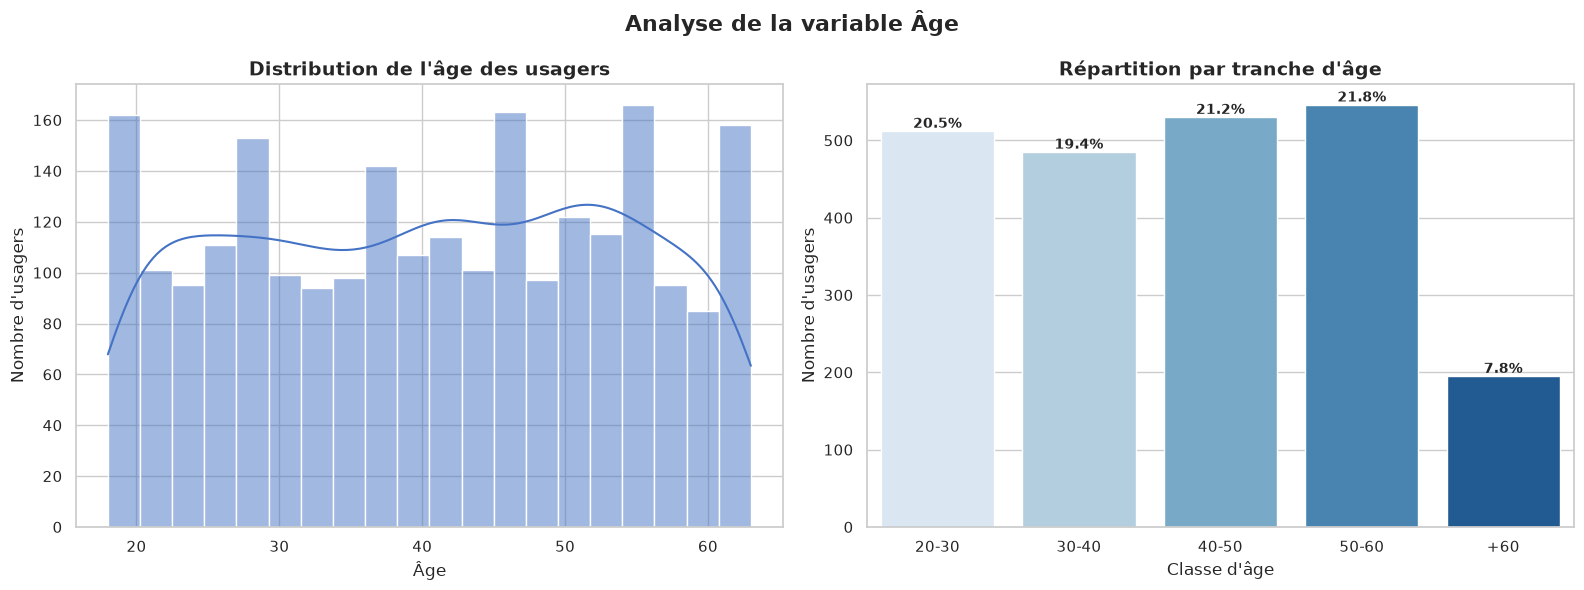

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Création des classes d'âge
# ------------------------------------------------------------------

df_plot = df.copy()

bins = [20, 30, 40, 50, 60, 100]
labels = ["20-30", "30-40", "40-50", "50-60", "+60"]

df_plot["tranche_age"] = pd.cut(
    df_plot["age"],
    bins=bins,
    labels=labels,
    right=False
)

# ------------------------------------------------------------------
# Paramètres graphiques
# ------------------------------------------------------------------

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)

# ------------------------------------------------------------------
# Graphique 1 : distribution âge
# ------------------------------------------------------------------

sns.histplot(
    data=df_plot,
    x="age",
    bins=20,
    kde=True,
    color="#4472C4",
    ax=axes[0]
)

axes[0].set_title(
    "Distribution de l'âge des usagers",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Nombre d'usagers")

# ------------------------------------------------------------------
# Graphique 2 : classes d'âge
# ------------------------------------------------------------------

ax = sns.countplot(
    data=df_plot,
    x="tranche_age",
    palette="Blues",
    ax=axes[1]
)

# Ajout des pourcentages
total = len(df_plot)

for bar in ax.patches:

    count = int(bar.get_height())
    pct = count / total * 100

    ax.annotate(
        f"{pct:.1f}%",
        (
            bar.get_x() + bar.get_width() / 2,
            count
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

axes[1].set_title(
    "Répartition par tranche d'âge",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Classe d'âge")
axes[1].set_ylabel("Nombre d'usagers")

# ------------------------------------------------------------------
# Titre global
# ------------------------------------------------------------------

fig.suptitle(
    "Analyse de la variable Âge",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()




**Observations** : 
> La distribution des âges permet d'identifier une population majoritairement ou minoritairement représentée dans le jeu de données.
> Aucune abération majeure n'est observée à ce stade (âges négatifs, valeurs irréalistes).
> La distribution est relativement équilibrée, il n'y a pas de sur ou sous repréentation d'age ou classe d'age en particulier (à l'excetion des +60 ans).

#### 3.3.2 Ancienneté poste 

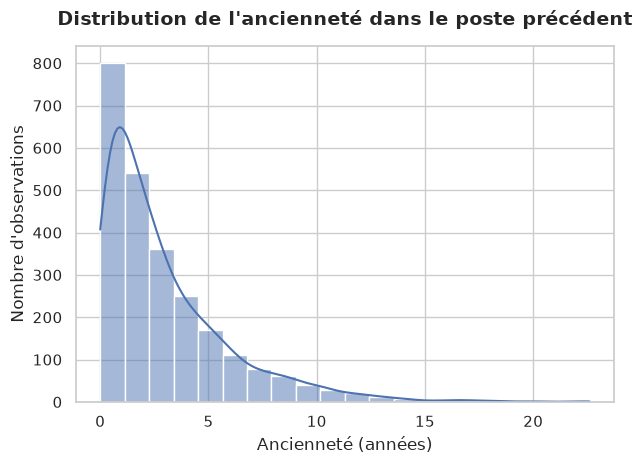

In [9]:
sns.histplot(
    data=df,
    x="anciennete_poste_ans",
    bins=20,
    kde=True
)

plt.title(
    "Distribution de l'ancienneté dans le poste précédent",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Ancienneté (années)")
plt.ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()



**Observations** : 
> Cette variable présente une distribution asymétrique, avec une concentration importante d'individus ayant une faible ancienneté et une faible proportion correspondant à des parcours professionnels plus stables.

#### 3.3.3 Niveau de diplome

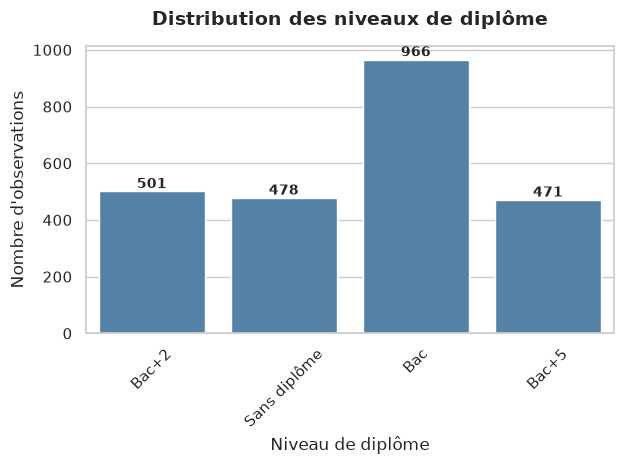

In [10]:
ax = sns.countplot(
    data=df,
    x="niveau_diplome",
    color="steelblue"
)

# Affichage des valeurs au-dessus des barres
for bar in ax.patches:
    hauteur = int(bar.get_height())

    ax.annotate(
        str(hauteur),
        (
            bar.get_x() + bar.get_width() / 2,
            hauteur
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.xticks(rotation=45)

plt.title(
    "Distribution des niveaux de diplôme",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Niveau de diplôme")
plt.ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()

**Observation :**
> Le niveau Bac constitue une classe majoritaire par rapport aux autres classes.

#### 3.3.4 Longueur de la synthèse

<Axes: xlabel='longueur_synthese', ylabel='Count'>

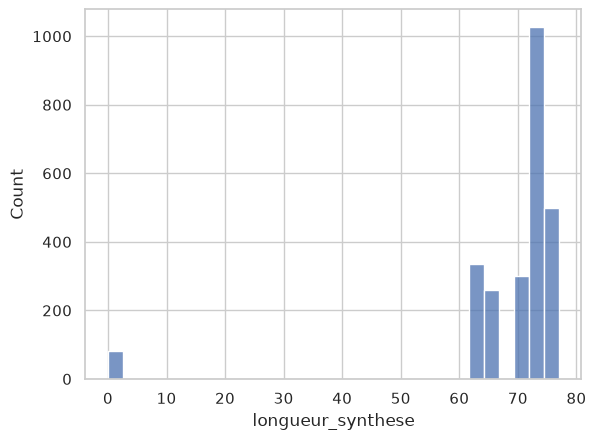

In [11]:
df["longueur_synthese"] = (
    df["synthese_entretien"]
    .fillna("")
    .str.len()
)

sns.histplot(
    data=df,
    x="longueur_synthese",
    bins=30
)


**Observations :
> La grande majorité des observations disposent d'une synthèse composée d'environ 300 jusqu'à 1000 caractères.

### 3.4 Variable cible : équilibre des classes / distribution

/tmp/ipykernel_59341/1788006777.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


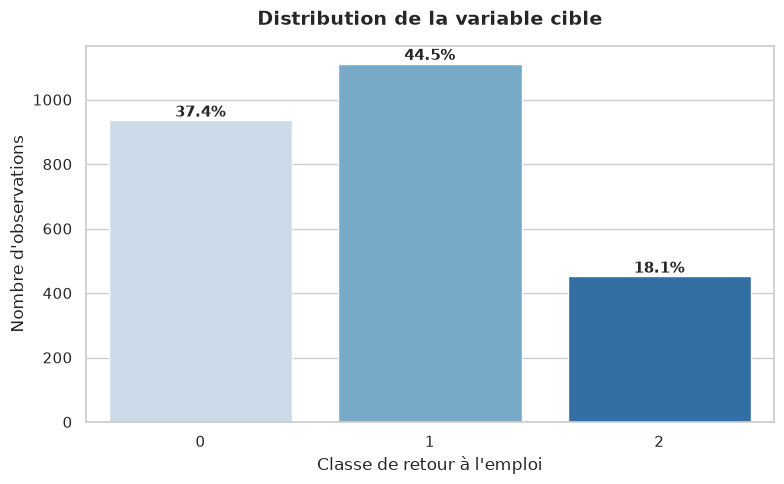

In [12]:
# Graphique de distribution de la classe

# Taille de la figure
plt.figure(figsize=(8, 5))

# Graphique
ax = sns.countplot(
    data=df,
    x="classe_retour_emploi",
    palette="Blues"
)

# Total pour calculer les pourcentages
total = len(df)

# Ajout des pourcentages au-dessus des barres
for bar in ax.patches:
    count = int(bar.get_height())
    percentage = 100 * count / total

    ax.text(
        x=bar.get_x() + bar.get_width() / 2,
        y=count,
        s=f"{percentage:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Titres et labels
ax.set_title(
    "Distribution de la variable cible",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Classe de retour à l'emploi")
ax.set_ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()

L'analyse de la variable cible montre un déséquilibre modéré des trois classes : **44,5 %** pour la classe 1, **37,4 %** pour la classe 0 et **18,1 %** pour la classe 2. Bien que la classe 2 soit minoritaire, elle représente près d'un cinquième du jeu de données et ne peut donc pas être considérée comme une classe rare. Néanmoins, cette classe correspond aux demandeurs d'emploi présentant un risque de chômage de longue durée, ce qui en fait la catégorie métier la plus sensible. Par conséquent, l'évaluation des modèles accordera une attention particulière au `Recall` de la classe 2 ainsi qu'au `F1-score Macro` afin de garantir une bonne détection des profils à risque.

### 3.5 Corrélations & relations entre variables

Après l'analyse de la qualité et de la distribution des données, il convient d'étudier les relations entre variables afin d'identifier les facteurs susceptibles d'exercer une influence sur la variable cible « retour à l'emploi ».

#### 3.5.1 Corrélations entre variables numériques

Vérification des relations fortes entre variables quantitatives.

<Axes: >

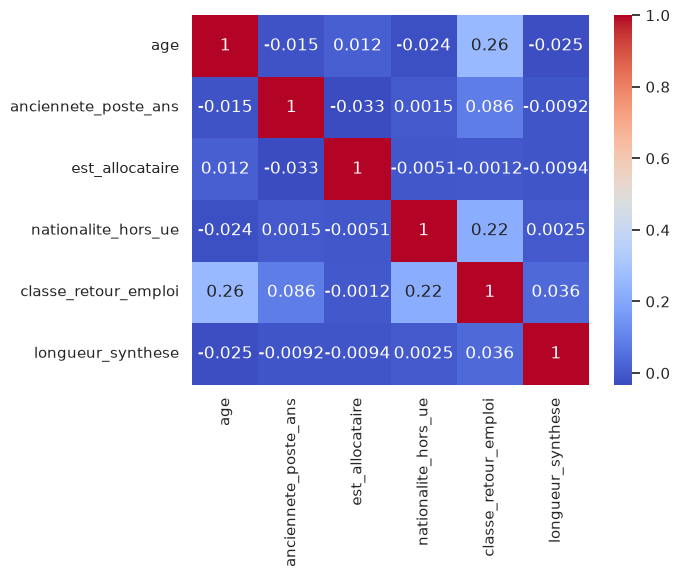

In [13]:
# Matrice de corrélation, pairplot, croisements clés vs cible

num_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

corr_matrix = df[num_cols].corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

**Observation :**
> Les corrélations observées sont globalement faibles, ce qui suggère une faible redondance de l'information.
Cela suggère que chaque variable apporte une information potentiellement complémentaire au modèle.

#### 3.5.2 Influence des variables numériques sur la cible 

##### Age et retour à l'emploi

L'âge est fréquemment cité comme un facteur influençant la réinsertion professionnelle. Les demandeurs les plus âgés présentent-ils davantage de risque de chômage longue durée ?

/tmp/ipykernel_59341/3721484568.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


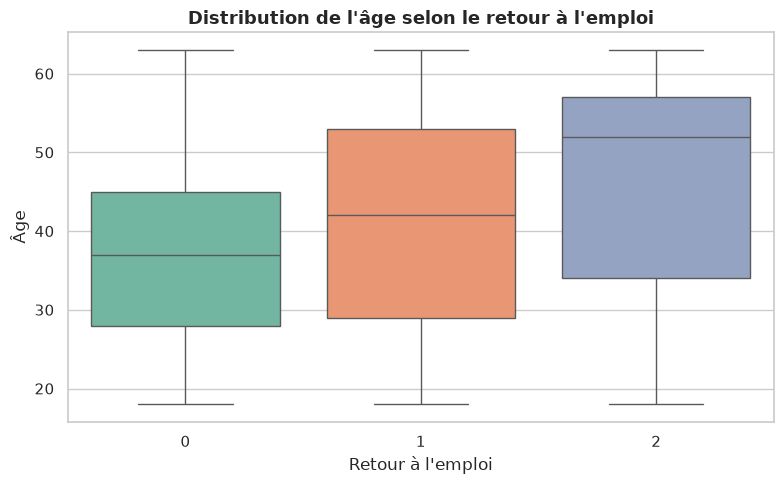

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="classe_retour_emploi",
    y="age",
    palette="Set2"
)

plt.title(
    "Distribution de l'âge selon le retour à l'emploi",
    fontsize=13,
    weight="bold"
)

plt.xlabel("Retour à l'emploi")
plt.ylabel("Âge")

plt.tight_layout()
plt.show()


**Observations :**
> On observe dans ce graphique une certaine correlation entre l'age et le retour à l'emploi. Autrement dit, les bénéficiaires ayant retrouvé un emploi rapidement semblent légèrement plus jeunes en moyenne.


##### Ancienneté dans le dernier poste et retour à l'emploi

L'ancienneté peut refléter l'expérience professionnelle accumulée. La stabilité professionnelle passée influence-t-elle le retour à l'emploi ?

/tmp/ipykernel_59341/2333665931.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


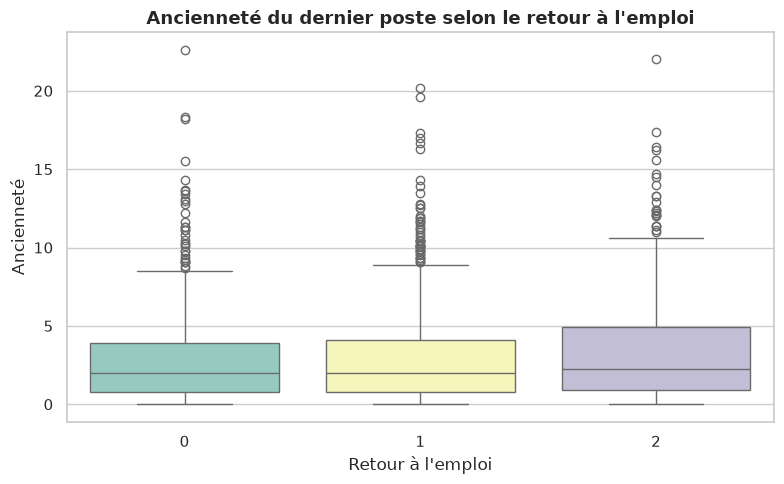

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="classe_retour_emploi",
    y="anciennete_poste_ans",
    palette="Set3"
)

plt.title(
    "Ancienneté du dernier poste selon le retour à l'emploi",
    fontsize=13,
    weight="bold"
)

plt.xlabel("Retour à l'emploi")
plt.ylabel("Ancienneté")

plt.tight_layout()
plt.show()

**Observations :**
> Les distributions sont ici similaires et ne permettent pas de conclure directement sur l'impact de la variable.

#### 3.5.3 Influence des variables catégorielles

##### Niveau de diplôme vs retour à l'emploi
Le niveau d'études constitue classiquement un facteur explicatif de l'insertion professionnelle. Le retour à l'emploi varie-t-il selon le niveau de diplôme ?

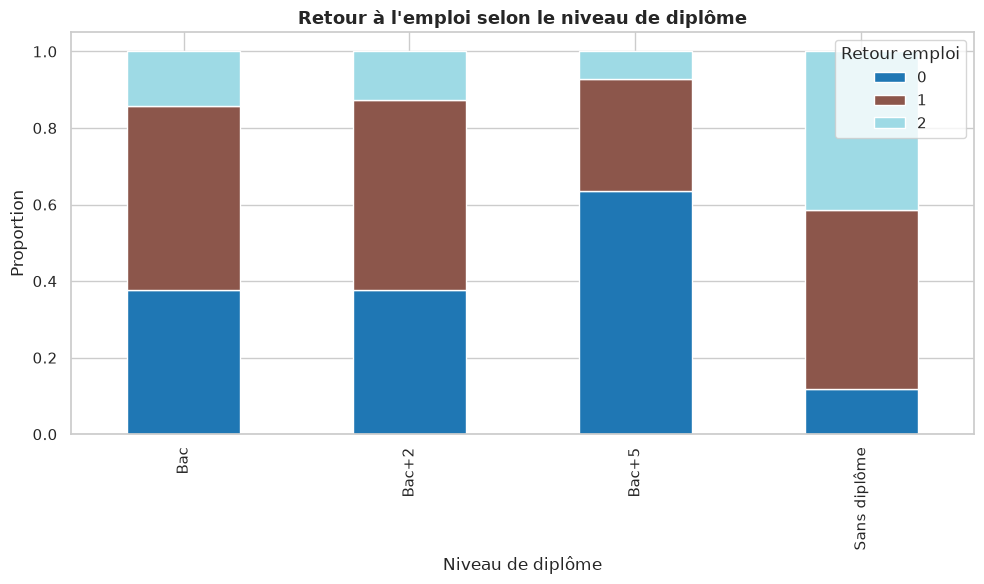

In [16]:
diplome_ct = pd.crosstab(
    df["niveau_diplome"],
    df["classe_retour_emploi"],
    normalize="index"
)

diplome_ct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="tab20"
)

plt.title(
    "Retour à l'emploi selon le niveau de diplôme",
    fontsize=13,
    weight="bold"
)

plt.ylabel("Proportion")
plt.xlabel("Niveau de diplôme")

plt.legend(title="Retour emploi")

plt.tight_layout()
plt.show()

**Observations :**
> L'histogramme montre que les niveaux de diplôme les plus élevés présentent une proportion plus importante de retours à l'emploi rapide. A l'inverse, les population sans diplome présentent une proportion importante de retour à l'emploi plus long.

##### Allocataire vs retour à l'emploi
Le statut d'allocataire peut refléter des situations socio-économiques différentes. Le retour à l'emploi varie-t-il selon le statut allocataire ?

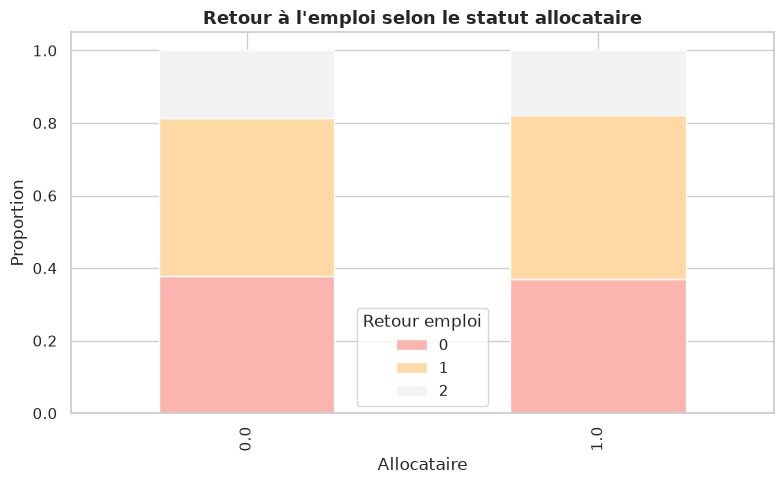

In [17]:
alloc_ct = pd.crosstab(
    df["est_allocataire"],
    df["classe_retour_emploi"],
    normalize="index"
)

alloc_ct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    colormap="Pastel1"
)

plt.title(
    "Retour à l'emploi selon le statut allocataire",
    fontsize=13,
    weight="bold"
)

plt.ylabel("Proportion")
plt.xlabel("Allocataire")

plt.legend(title="Retour emploi")

plt.tight_layout()
plt.show()

**Observations :**
> L'histogramme ne montre pas d'impact du statut allocataire sur le retour à l'emploi

#### 3.5.6 Variable sensible : nationalité hors UE

Cette variable est considérée comme sensible et mérite une attention particulière afin de détecter d'éventuelles disparités. Existe-t-il une différence notable de répartition des classes selon la nationalité hors UE ?


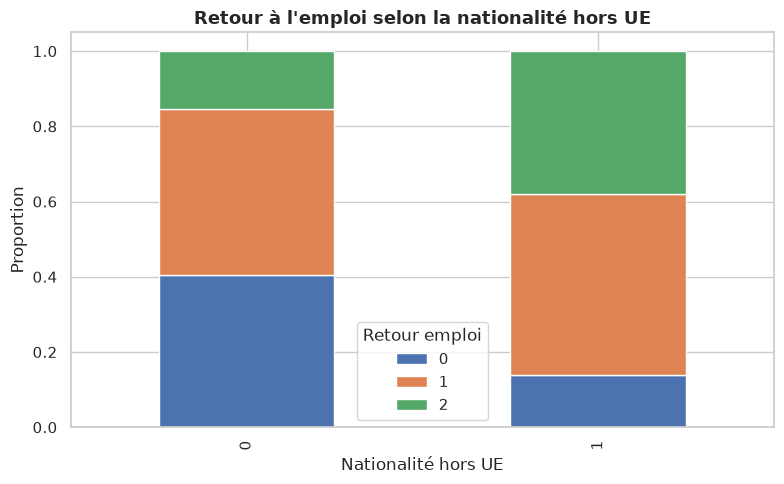

In [18]:
hors_ue_ct = pd.crosstab(
    df["nationalite_hors_ue"],
    df["classe_retour_emploi"],
    normalize="index"
)

hors_ue_ct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title(
    "Retour à l'emploi selon la nationalité hors UE",
    fontsize=13,
    weight="bold"
)

plt.ylabel("Proportion")
plt.xlabel("Nationalité hors UE")

plt.legend(title="Retour emploi")

plt.tight_layout()
plt.show()

**Observations :**
> Une différence de répartition est observée entre les 2 groupes dans/hors UE. Cette variable devra faire l'objet d'une analyse approfondie afin d'évaluer un éventuel risque de biais avant son utilisation dans le modèle.

#### 3.5.5 Observation finale


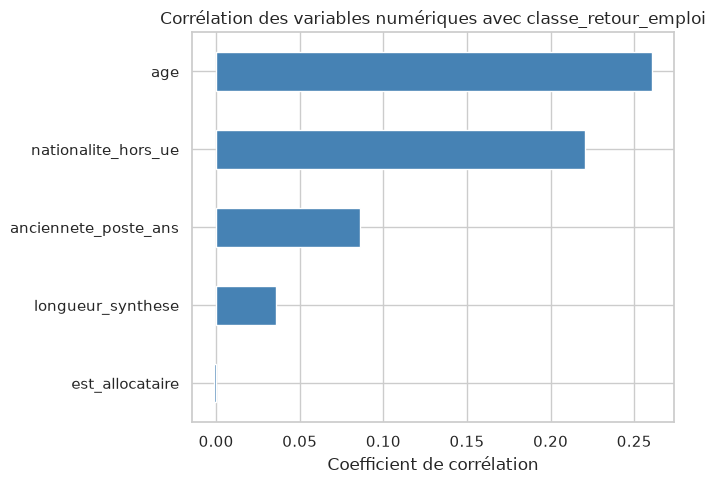

In [19]:
corr_target = (
    corr_matrix["classe_retour_emploi"]
    .drop("classe_retour_emploi")
    .sort_values()
)

plt.figure(figsize=(7, 5))

corr_target.plot(
    kind="barh",
    color="steelblue"
)

plt.title(
    f"Corrélation des variables numériques avec {"classe_retour_emploi"}"
)

plt.xlabel("Coefficient de corrélation")

plt.tight_layout()
plt.show()

L'analyse exploratoire met en évidence plusieurs variables susceptibles d'influencer le retour à l'emploi : notamment l'age, la nationalité et le niveau de diplôme. Ces résultats guideront la sélection des variables utilisées dans les modèles prédictifs tout en restant attentif aux risques de biais associés aux variables sensibles.

### 3.6 Analyse des biais & variables sensibles

*[Quelles variables peuvent porter un biais (genre, âge, origine, profession des parents…) ? La cible est-elle inégalement répartie selon ces variables ? Disparate impact ?]*

L'analyse exploratoire a permis d'identifier plusieurs variables susceptibles d'introduire des biais dans les prédictions du modèle. 

Parmi celles-ci, la variable `nationalite_hors_ue` mérite une attention particulière puisqu'elle constitue une caractéristique potentiellement sensible au regard des enjeux de non-discrimination. Son utilisation pourrait conduire le modèle à reproduire ou amplifier des biais présents dans les données historiques.

Par ailleurs, la variable `age`, bien que nécessairement informative dans le contexte du retour à l'emploi, peut également être source de biais indirects si certaines classes de population sont historiquement sur-représentées parmi les demandeurs d'emploi de longue durée.

Les analyses croisées réalisées entre ces variables et la cible montrent qu'il convient de surveiller d'éventuelles disparités de distribution entre les groupes. Toutefois, l'EDA ne permet pas à elle seule de conclure à l'existence d'une discrimination algorithmique.

Une analyse plus approfondie sera conduite lors de la phase de modélisation à travers la comparaison de scénarios avec et sans variable sensible, ainsi que l'évaluation des performances sur différents sous-groupes de population. Dans un objectif de conformité aux principes d'équité, de transparence et de responsabilité, une attention particulière sera portée à l'impact de ces variables sur les prédictions du modèle et sur les décisions d'accompagnement qui pourraient en découler.

### 3.7 📝 Synthèse EDA

*[Top 5 enseignements de l'EDA. Hypothèses de travail pour la modélisation. Risques de biais identifiés. **Révision éventuelle des cibles 1.4** à la lumière de la donnée.]*

L'analyse exploratoire a permis de dégager plusieurs enseignements importants pour la suite du projet :

1. Le jeu de données présente une bonne qualité globale, avec un faible taux de valeurs manquantes (inférieur à 5 % pour toutes les variables concernées) et aucune donnée manquante sur la variable cible.
2. La variable cible est relativement équilibrée, même si la classe 2 (risque de chômage longue durée) reste minoritaire avec 18,08 % des observations. Ce déséquilibre demeure modéré mais justifie une attention particulière lors de l'évaluation des modèles.
3. Les variables métier disponibles sont variées et complémentaires, combinant données numériques, catégorielles et textuelles. Cette richesse informationnelle laisse envisager un potentiel prédictif intéressant pour la modélisation multimodale.
4. Certaines variables semblent susceptibles de contribuer significativement à la prédiction du retour à l'emploi, notamment l'âge, le niveau de diplôme, l'ancienneté dans le poste précédent ou encore les informations contenues dans les synthèses d'entretien.
5. Des risques de biais ont été identifiés, en particulier autour de la variable `nationalite_hors_ue` et, dans une moindre mesure, de la variable age. Ces éléments justifient la mise en place d'analyses dédiées lors de la comparaison des différents scénarios de modélisation.

À l'issue de cette phase exploratoire, plusieurs hypothèses de travail sont retenues pour la suite du projet :

	• les données sont suffisamment complètes pour privilégier une stratégie d'imputation plutôt qu'une suppression de lignes ;
	• les variables textuelles devraient apporter une information complémentaire aux variables tabulaires ;
	• les performances du modèle devront être évaluées au-delà de la seule accuracy, en particulier à travers le Recall de la classe 2 et le F1-score Macro ;
	• des scénarii de comparaison avec suppression de variables sensibles sera nécessaire afin d'évaluer l'impact potentiel des biais.

Enfin, les objectifs définis lors du cadrage métier restent pertinents à ce stade de l'étude. Néanmoins, les cibles de performance seront réévaluées après les premiers entraînements afin de tenir compte des caractéristiques réelles observées dans les données et des performances effectivement atteignables.


Ci-dessous un récapitulatif des variables analysées :

In [20]:
summary_rows = []

for column in df.columns:

    missing_pct = round(df[column].isna().mean() * 100, 2)

    dtype = str(df[column].dtype)

    # Variables numériques
    if pd.api.types.is_numeric_dtype(df[column]):

        distribution = (
            f"Moy={df[column].mean():.2f} | "
            f"Min={df[column].min():.2f} | "
            f"Max={df[column].max():.2f}"
        )

    # Variables catégorielles / texte
    else:

        n_modalites = df[column].nunique(dropna=True)

        distribution = (
            f"{n_modalites} modalité(s)"
        )

    summary_rows.append(
        {
            "Variable": column,
            "Type": dtype,
            "Valeurs manquantes (%)": missing_pct,
            "Distribution": distribution
        }
    )

df_variables = pd.DataFrame(summary_rows)

df_variables

,Variable,Type,Valeurs manquantes (%),Distribution
0,usager_id,str,0.00,2500 modalité(s)
1,age,float64,4.88,Moy=40.57 | Min=18.00 | Max=63.00
2,niveau_diplome,str,3.36,4 modalité(s)
3,anciennete_poste_ans,float64,0.00,Moy=2.97 | Min=0.00 | Max=22.60
4,code_rome_vise,str,0.00,50 modalité(s)
5,code_insee_commune,str,0.00,2407 modalité(s)
6,est_allocataire,float64,1.76,Moy=0.60 | Min=0.00 | Max=1.00
7,nationalite_hors_ue,int64,0.00,Moy=0.12 | Min=0.00 | Max=1.00
8,synthese_entretien,str,3.24,9 modalité(s)
9,classe_retour_emploi,int64,0.00,Moy=0.81 | Min=0.00 | Max=2.00


---
## 4. Préparation des données

🎯 Construire un **pipeline de prétraitement reproductible** et comparable pour l'ensemble des scénarios d'entraînement.

💡 Cette section consiste à :
- sélectionner les variables retenues pour la modélisation ;
- définir les traitements adaptés à chaque type de données (numériques, catégorielles et textuelles) ;
- intégrer certaines considérations éthiques dans la préparation des données ;
- réaliser un découpage train/test stratifié afin de prévenir toute fuite de données ;
- encapsuler l'ensemble des transformations dans un pipeline unique réutilisable pour tous les modèles et scénarios.

💡 `sklearn.compose.ColumnTransformer` + `sklearn.pipeline.Pipeline` = base  
⚠️ Le **train/test split DOIT précéder** tout calcul d'imputation/normalisation, sinon fuite de données.

### 4.1 Préparation des features

Cette phase consiste à définir les variables retenues pour la modélisation et à spécifier les traitements qui leur seront appliqués. Les choix effectués visent à garantir la qualité des données, la compatibilité avec les algorithmes d'apprentissage et la reproductibilité des expérimentations.

Avant de séparer le jeu de données entrainement/test, on prépare les features qui seront utilisées dans ces jeux.

#### 4.1.1 Sélection et traitement des variables 

| Variable | Type | Valeurs manquantes | Traitement dans le pipeline | Justification |
|-----------|------|-------------------|----------------------------|---------------|
| `usager_id` | Identifiant | Aucune | Suppression | Identifiant unique sans pouvoir prédictif, susceptible d'introduire du bruit dans l'apprentissage. |
| `age` | Numérique | 122 (4,9 %) | Imputation par la médiane → Standardisation (`StandardScaler`) | La médiane est robuste aux valeurs extrêmes. La standardisation harmonise les échelles des variables numériques. |
| `niveau_diplome` | Catégorielle | 84 (3,4 %) | Imputation par la modalité « Non renseigné » → Encodage One-Hot | L'absence d'information peut être porteuse de sens. Le One-Hot évite de créer un ordre artificiel entre les catégories. |
| `anciennete_poste_ans` | Numérique | Aucune | Standardisation (`StandardScaler`) | Mise à l'échelle des variables numériques pour améliorer la convergence et la comparabilité des coefficients. |
| `code_rome_vise` | Catégorielle | Aucune | Encodage One-Hot | Variable nominale sans ordre naturel. L'encodage binaire permet son exploitation par les algorithmes. |
| `code_insee_commune` → `departement` | Catégorielle | Aucune | Transformation en département → Encodage One-Hot | Réduction de la cardinalité, amélioration de la généralisation et limitation des biais liés à une géolocalisation trop fine. Cette agrégation s'inscrit également dans une démarche de minimisation des données. |
| `est_allocataire` | Binaire | 44 (1,8 %) | Imputation par le mode → Conservation au format 0/1 | Le faible nombre de valeurs manquantes justifie une imputation simple sans altérer la distribution de la variable. |
| `nationalite_hors_ue` | Binaire | Aucune | Conservation au format 0/1 (Scénarios 1 et 4) / Suppression (Scénario 2) | Variable directement exploitable. Retirée dans l'approche éthique afin de limiter les risques de discrimination indirecte. |
| `synthese_entretien` | Texte | 81 (3,2 %) | Remplacement par une chaîne vide → Vectorisation TF-IDF | Permet de conserver toutes les observations sans générer artificiellement de contenu textuel. TF-IDF transforme le texte en représentation numérique exploitable. |
| `classe_retour_emploi` | Variable cible | Aucune | Aucune transformation | Variable cible du problème de classification multiclasse. |

#### 4.1.2 Traitement du Code INSEE

La variable `code_insee_commune` est transformée en variable `departement`. Ce choix répond à un double objectif. 
- Premièrement, il réduit la cardinalité de la variable géographique et améliore la capacité de généralisation du modèle.
- Deuxièmement, il limite l'utilisation d'informations territoriales trop précises pouvant constituer des indicateurs indirects de situation sociale ou économique.

Cette agrégation géographique permet de conserver un contexte territorial pertinent pour l'analyse du retour à l'emploi tout en s'inscrivant dans une démarche d'IA responsable fondée sur les principes de minimisation des données, de proportionnalité et de réduction des biais algorithmiques.

In [21]:
# 4.1 Preparation des features

def extraire_departement(code_insee: str) -> str:
    """
    Extrait le code département à partir d'un code INSEE commune.

    Parameters
    ----------
    code_insee : str
        Code INSEE de la commune.

    Returns
    -------
    str
        Code département.
    """
    code_insee = str(code_insee)

    # Cas particuliers Corse
    if code_insee.startswith("2A"):
        return "2A"
    if code_insee.startswith("2B"):
        return "2B"
    # Départements métropolitains classiques
    return code_insee[:2]


# Création de la variable département
df["departement"] = df["code_insee_commune"].apply(extraire_departement)
# Vérification
print(df[["code_insee_commune", "departement"]].head())

# Nombre de départements représentés
print(
    f"Nombre de départements : "
    f"{df['departement'].nunique()}"
)

  code_insee_commune departement
0              18273          18
1              07240          07
2              01405          01
3              63359          63
4              21302          21
Nombre de départements : 96


In [22]:
df["synthese_entretien"] = df["synthese_entretien"].fillna("")
df["longueur_synthese"] = df["synthese_entretien"].str.len()
df[["synthese_entretien", "longueur_synthese"]].head(3)

,synthese_entretien,longueur_synthese
0,Compétences à réactualiser sur les outils numé...,74
1,Cumul de difficultés. Pas de moyen de transpor...,76
2,Compétences à réactualiser sur les outils numé...,74


#### 4.1.3 Initialisation des variables

In [23]:
# variables
feat_num = ["age", "anciennete_poste_ans"]
feat_cat = ["niveau_diplome", "code_rome_vise", "departement", "est_allocataire", "nationalite_hors_ue"]
feat_txt = "synthese_entretien"
target = "classe_retour_emploi"
feat_sen = ["age", "nationalite_hors_ue"]


### 4.2 Train/test split

Avant toute étape d'apprentissage, le jeu de données est séparé en ensembles d'entraînement et de test. Ce découpage permet d'évaluer les performances des modèles sur des données non observées lors de l'entraînement tout en prévenant les risques de fuite de données.

Le test est scellé jusqu'à l'étape [5]. `stratify=y` garantit que les 3 classes gardent leurs proportions dans les deux jeux — indispensable avec une classe à 18 %.

In [24]:
# 4.2 Train/test split (stratifié si classification déséquilibrée)
# from sklearn.model_selection import train_test_split
# X = df.drop(columns=["target"])
# y = df["target"]
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
# )

X = df[feat_num + feat_cat + [feat_txt]]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)
y_train.value_counts(normalize=True).round(3)

(2000, 8) (500, 8)


classe_retour_emploi
1    0.444
0    0.374
2    0.181
Name: proportion, dtype: float64

### 4.3 Instanciation du pipeline

Les opérations de prétraitement sont regroupées au sein d'un pipeline unique afin d'assurer l'application systématique et reproductible des transformations. Cette approche facilite également la comparaison des modèles dans un protocole expérimental homogène.


#### 4.3.1 Preprocessing



| Pipe | Colonnes | Traitement |
|---|---|---|
| `num` | âge, anciennete_poste_ans | imputation médiane + standardisation |
| `cat` | niveau_diplome, code_rome_vise, departement, est_allocataire, nationalite_hors_ue | imputation mode + OneHot (`handle_unknown=\"ignore\"`) |
| `txt` | synthese_entretien | TF-IDF (5 000 termes max) |


In [25]:
# 4.2 Pipeline de préprocessing : numériques + catégorielles

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
txt_pipe = TfidfVectorizer(max_features=5000, min_df=3)

def build_preprocessor(num_features=None, cat_features=None, txt_features=None):
    """Instancie la MEME recette sur le perimetre demande.
    Chaque bloc est OPTIONNEL : c'est ce qui permet a un scenario de 4.3 de
    retirer un type de donnees entier sans changer les traitements.
    Meme recette partout = comparabilite.
    """
    blocks = []
    if num_features:
        blocks.append(("num", num_pipe, num_features))
    if cat_features:
        blocks.append(("cat", cat_pipe, cat_features))
    if txt_features:
        blocks.append(("txt", txt_pipe, txt_features))

    assert blocks, "Aucune colonne : verifie le perimetre du scenario"
    return ColumnTransformer(blocks)



### 4.4 Scénarios de jeux de données

Quatre scénarios sont définis afin d'évaluer l'influence des différentes catégories de données sur la qualité des prédictions. Cette démarche permet d'analyser l'apport respectif des variables structurées, des données textuelles et des variables sensibles dans le processus de modélisation.

| Scénario | Description | Variables conservées | Justification |
|---|---|---|---|
| S1 | Approche multimodale complète | Toutes | Scénario de référence (baseline). Toutes les informations disponibles sont exploitées afin d'obtenir le potentiel prédictif maximal et de mesurer l'apport combiné des données structurées et textuelles. |
| S2 | Approche Éthique | toutes sauf age et nationalité | Retrait des variables pouvant être considérées comme sensibles ou fortement corrélées à des critères protégés : age (donnée personnelle pouvant conduire à une discrimination liée à l'âge) et nationalite_hors_ue (critère directement lié à l'origine/nationalité). Cette approche s'inscrit dans les principes de minimisation des données, de non-discrimination et de protection des personnes promus par le RGPD et les recommandations de la CNIL. |
| S3 | Diagnostic par le texte seul  | synthese_entretien | Évaluation de la capacité du modèle à prédire le retour à l'emploi uniquement à partir du contenu sémantique des verbatims. Permet de mesurer la richesse informationnelle des synthèses d'entretien et la robustesse du modèle face au bruit textuel. | 
| S4 | Données contextuelles pures  | Synthèse exclue | Permet d'évaluer le pouvoir prédictif des seules données structurées sans apport du contexte sémantique. Ce scénario servira de point de comparaison pour quantifier la valeur ajoutée du traitement NLP. | 



In [26]:
# préparation des scénarios

# Un scenario = un perimetre, decrit comme les arguments de build_preprocessor.
scenarios = {
    "S1": dict(num_features=["age", "anciennete_poste_ans"], cat_features=["niveau_diplome", "code_rome_vise", "departement", "est_allocataire", "nationalite_hors_ue"], txt_features="synthese_entretien"),
    "S2": dict(num_features=["anciennete_poste_ans"], cat_features=["niveau_diplome", "code_rome_vise", "departement", "est_allocataire"], txt_features="synthese_entretien"),  
    "S3": dict(txt_features="synthese_entretien"),
    "S4": dict(num_features=["age", "anciennete_poste_ans"], cat_features=["niveau_diplome", "code_rome_vise", "departement", "est_allocataire", "nationalite_hors_ue"]),
}

df_scenarios = (
    pd.DataFrame.from_dict(scenarios, orient="index")
    .rename_axis("scenario")
    .reset_index()
)

display(df_scenarios)


,scenario,num_features,cat_features,txt_features
0,S1,"[age, anciennete_poste_ans]","[niveau_diplome, code_rome_vise, departement, ...",synthese_entretien
1,S2,[anciennete_poste_ans],"[niveau_diplome, code_rome_vise, departement, ...",synthese_entretien
2,S4,"[age, anciennete_poste_ans]","[niveau_diplome, code_rome_vise, departement, ...",NaN
3,S3,NaN,NaN,synthese_entretien


### 4.5 📝 Synthèse préparation

*[Choix de pipeline, scénarios construits, traçabilité.]*

Les données ont été préparées au sein d'un pipeline unique garantissant un traitement homogène pour l'ensemble des expérimentations. Les valeurs manquantes, les variables catégorielles et les données textuelles sont prises en charge par des transformations adaptées à leur nature.

Quatre scénarios ont été définis afin de mesurer l'apport respectif des données tabulaires, textuelles et des variables sensibles. Cette démarche permettra de comparer les modèles dans un cadre méthodologique identique et d'analyser l'impact réel de chaque type d'information sur la prédiction du retour à l'emploi.

---
## 5. Modélisation & entraînement

🎯 **Comparer plusieurs modèles** avec validation croisée, choisir, justifier.

💡 Démarche scientifique : on pose une hypothèse, on teste, on compare. Pas un seul modèle « parce que je connais ».  
⚠️ Le scoring de validation croisée se fait **sur le train uniquement**. Le test set ne sert qu'à la fin.



| Famille | Adapté à mon problème ? | Coût total (train + inférence) | Explicabilité | Dépendance fournisseur | Décision (retenue / écartée + motif) |
|----------|----------|----------|----------|----------|----------|
| ML classique (scikit-learn, XGBoost, LightGBM, CatBoost) | Oui. Classification supervisée sur données tabulaires structurées avec un volume limité (~2 500 observations) et quelques variables textuelles pouvant être vectorisées (TF-IDF). | Faible | Élevée à moyenne selon le modèle | Aucune | **Retenue.** Famille la plus adaptée au problème, faible coût, bonne performance attendue, validation croisée facile, explicabilité compatible avec les contraintes métier et réglementaires. |
| Deep Learning (Keras, PyTorch) | Peu adapté. Généralement pertinent pour grands volumes de données, vision, audio ou NLP avancé. | Élevé (entraînement GPU souvent nécessaire) | Faible | Aucune | **Écartée.** Taille de dataset insuffisante pour justifier la complexité. Gain de performance improbable face à XGBoost/CatBoost sur données tabulaires. Ratio coût/bénéfice défavorable. |
| SLM local (Ollama, Mistral, Gemma, Phi, Llama ≤ 7B) | Partiellement adapté uniquement pour exploiter le texte libre sous forme générative. Pas optimisé pour prédire directement une cible de classification structurée. | Moyen | Faible à moyenne | Aucune | **Écartée.** Le besoin n'est pas de générer du texte mais de classer des dossiers. Une représentation TF-IDF intégrée dans un pipeline de ML classique est plus simple, plus explicable et moins coûteuse. |
| LLM API + RAG | Non. Le RAG répond à des questions sur une base documentaire et ne constitue pas un algorithme de classification supervisée adapté à ce problème. | Élevé (coût par appel et par token) | Faible | Forte (OpenAI, Anthropic, Mistral, etc.) | **Écartée.** Aucune base documentaire à interroger. Le problème consiste à prédire une classe à partir de variables d'entrée et non à rechercher de l'information. Surcoût sans bénéfice métier démontré. |
| Architecture agentique (multi-agents, outils externes, orchestrateurs) | Non. Pertinente pour l'exécution de tâches complexes multi-étapes ou l'automatisation de processus décisionnels. | Très élevé | Très faible | Forte | **Écartée.** Complexité disproportionnée par rapport au besoin. N'apporte aucune valeur directe pour une tâche de classification supervisée sur jeu de données statique. |

Après analyse des principales familles de solutions d'intelligence artificielle, le Machine Learning classique a été retenu comme approche principale. Le problème étudié est une tâche de classification supervisée sur un volume de données limité, composé majoritairement de variables tabulaires structurées et d'un champ textuel libre. Les approches de Deep Learning, SLM, LLM avec RAG et architectures agentiques ont été écartées car elles introduisent une complexité, un coût de calcul et une perte d'explicabilité qui ne sont pas justifiés par les caractéristiques du problème. Le benchmark comparatif sera donc réalisé sur plusieurs modèles de Machine Learning classique (régression logistique, Random Forest, XGBoost/CatBoost, etc.) évalués avec les mêmes folds de validation croisée et les mêmes métriques afin de sélectionner la solution la plus performante et la plus explicable.

### 5.1 Modèles candidats


**Modèles retenus**

| Modèle | Famille | Pourquoi candidat ? | Coût (entraînement / inférence) | Explicabilité |
|---|---|---|---|---|
| Régression Logistique | Linéaire | Baseline de référence, rapide, robuste, particulièrement adaptée aux variables TF-IDF et très interprétable | faible / faible | élevée |
| Random Forest | Ensemble (bagging) | Référence arbre robuste, peu sensible au bruit et au sur-apprentissage, nécessite peu de réglages | moyen / faible | moyenne |
| LightGBM | Ensemble (boosting) | Très performant et rapide sur données tabulaires, entraînement plus efficace que XGBoost sur certains jeux de données | moyen à élevé / faible | moyenne |
| XGBoost | Ensemble (boosting) | Référence industrielle pour les données tabulaires, excellente capacité à capturer les interactions complexes | élevé / faible | moyenne |
| CatBoost | Ensemble (boosting) | Très performant sur données mixtes tabulaires et catégorielles, peu de prétraitement nécessaire, concurrent sérieux de XGBoost | moyen / faible | moyenne |


### 5.2 Entraînement & validation croisée

In [55]:
# 5.2 Entraînement & validation croisée
# Pour chaque modèle : Pipeline(preprocessor + estimator) + cross_val_score

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    
    "LightGBM": LGBMClassifier(
        class_weight="balanced",
        random_state=42,
        verbose=-1
    ),
    
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        device="cpu",
        tree_method="hist",
        n_jobs=-1
    )
}

# validation croisée
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

from sklearn.metrics import make_scorer, recall_score

# Recall spécifique à la classe métier (classe 2)
recall_classe_2 = make_scorer(
    recall_score,
    labels=[2],
    average="macro",
    zero_division=0
)

scoring = {
    "f1_macro": "f1_macro",
    "recall_macro": "recall_macro",
    "recall_classe_2": recall_classe_2,
    "balanced_accuracy": "balanced_accuracy",
}


from src.benchmark import run_benchmark

df_benchmark = run_benchmark(
    models=models,
    scenarios=scenarios,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
    scoring=scoring,
    build_preprocessor=build_preprocessor
)

display(df_benchmark)


'''
resultats = []

for nom_sc, perimetre in scenarios.items():

    prep = build_preprocessor(**perimetre)

    for nom_mod, model in models.items():
        # print(model)
        # print(model.get_params())
        pipe = Pipeline(steps=[("prep", prep),("clf", model)])
        scores = cross_validate(estimator=pipe, X=X_train, y=y_train, cv=cv, scoring=scoring, n_jobs=-1)
        
        resultats.append({
            "scen": nom_sc,
            "modele": nom_mod,
            "f1_macro": round(scores["test_f1_macro"].mean(), 3),
            "écart-type": round(scores["test_f1_macro"].std(), 3),
            "recall_macro": round(scores["test_recall_macro"].mean(), 3),
            "recall classe 2": round(scores["test_recall_classe_2"].mean(), 3),
            "bal. acc.": round(scores["test_balanced_accuracy"].mean(), 3),
            "temps fit (s)": round(scores["fit_time"].mean(), 3),
            # Temps de prédiction moyen calculé sur les folds CV
            "temps inf. (s)": round(scores["score_time"].mean(), 4)
            # "Score Métier": 0.4 * f1_macro + 0.6 * recall_classe_2
        })


# ------------------------------------------------------------------
# DataFrame final
# ------------------------------------------------------------------

df_benchmark = pd.DataFrame(resultats)

# ------------------------------------------------------------------
# Affichage
# ------------------------------------------------------------------

print("\nRESULTATS DU BENCHMARK\n")
print(df_benchmark.to_string(index=False))
'''


,f1_macro,écart-type,recall_macro,recall classe 2,bal. acc.,temps fit (s),temps inf. (s),scen,modele
0,0.673,0.011,0.691,0.696,0.691,0.105,0.0244,S1,LogisticRegression
1,0.673,0.017,0.681,0.627,0.681,1.236,0.1688,S1,RandomForest
2,0.700,0.022,0.703,0.647,0.703,7.748,0.0330,S1,LightGBM
3,0.695,0.015,0.687,0.555,0.687,0.531,0.0267,S1,XGBoost
4,0.645,0.012,0.660,0.636,0.660,0.061,0.0210,S2,LogisticRegression
5,0.636,0.019,0.647,0.605,0.647,1.298,0.1567,S2,RandomForest
6,0.626,0.023,0.635,0.583,0.635,16.514,0.0313,S2,LightGBM
7,0.617,0.024,0.613,0.450,0.613,0.346,0.0253,S2,XGBoost
8,0.635,0.017,0.654,0.661,0.654,0.021,0.0149,S3,LogisticRegression
9,0.635,0.017,0.654,0.661,0.654,1.142,0.1448,S3,RandomForest


'\nresultats = []\n\nfor nom_sc, perimetre in scenarios.items():\n\n    prep = build_preprocessor(**perimetre)\n\n    for nom_mod, model in models.items():\n        # print(model)\n        # print(model.get_params())\n        pipe = Pipeline(steps=[("prep", prep),("clf", model)])\n        scores = cross_validate(estimator=pipe, X=X_train, y=y_train, cv=cv, scoring=scoring, n_jobs=-1)\n\n        resultats.append({\n            "scen": nom_sc,\n            "modele": nom_mod,\n            "f1_macro": round(scores["test_f1_macro"].mean(), 3),\n            "écart-type": round(scores["test_f1_macro"].std(), 3),\n            "recall_macro": round(scores["test_recall_macro"].mean(), 3),\n            "recall classe 2": round(scores["test_recall_classe_2"].mean(), 3),\n            "bal. acc.": round(scores["test_balanced_accuracy"].mean(), 3),\n            "temps fit (s)": round(scores["fit_time"].mean(), 3),\n            # Temps de prédiction moyen calculé sur les folds CV\n            "temps i

### 5.3 Métriques retenues & justification

*[Classification : accuracy, F1 macro/micro/weighted, ROC-AUC, matrice de confusion. Régression : RMSE, MAE, R². Justifier le choix selon la cible et l'enjeu métier.]*

| Métrique | Conserver ? | Pourquoi ? |
|-----------|------------|-------------|
| Balanced Accuracy | ✅ Oui | Donne le même poids à chaque classe, indépendamment de leur fréquence. Plus pertinente que l'accuracy lorsque les classes sont déséquilibrées. Permet d'évaluer l'équilibre global du modèle. |
| Accuracy | ❌ Non | Peut être trompeuse en présence de classes déséquilibrées. Une bonne accuracy peut masquer de mauvaises performances sur la classe métier critique. |
| F1-score macro | ✅ Oui (métrique principale) | Compromis entre précision et rappel en donnant le même poids à chaque classe. Adaptée à un problème multiclasse avec déséquilibre et permet de comparer les modèles de manière équitable. |
| F1-score weighted | ❌ Non | Pondère les performances selon la fréquence des classes. Les classes majoritaires influencent davantage le score, ce qui peut masquer les difficultés sur la classe 2. |
| Recall macro | ✅ Oui | Mesure la capacité du modèle à retrouver correctement les observations de chaque classe. Complète le F1 Macro en mettant l'accent sur le taux de détection global plutôt que sur le compromis précision/rappel. |
| Recall classe 2 | ✅ Oui (métrique métier) | Mesure la capacité du modèle à détecter les usagers à risque de chômage longue durée (classe 2). Les faux négatifs étant particulièrement coûteux métier, cette métrique est prioritaire pour la sélection du modèle. |
| Temps de prédiction | ✅ Oui | Permet d'évaluer la rapidité d'inférence du modèle. Critère important dans une perspective de mise en production et de passage à l'échelle. |
| Temps d'entraînement | ✅ Oui | Permet de comparer le coût de calcul des modèles. Utile pour arbitrer entre gain de performance et complexité opérationnelle. |
| Matrice de confusion | ✅ Oui | Indispensable pour comprendre quelles classes sont confondues et analyser les erreurs du modèle. Complète les métriques agrégées. |



### 5.4 Comparaison des modèles : tableau de scores CV

#### 5.4.1 Protocole de sélection du meilleur modèle

La sélection du meilleur repose sur une approche multicritère afin de ne pas privilégier uniquement la performance globale, mais également de tenir compte des enjeux métier et des contraintes opérationnelles du projet.

Trois dimensions sont considérées :

1. **Performance globale** : mesurée par le **F1-score macro**, retenu comme métrique principale. Cette métrique combine précision et rappel tout en accordant le même poids à chaque classe, indépendamment de leur fréquence. Elle est particulièrement adaptée aux problèmes de classification multiclasse présentant un léger déséquilibre.

2. **Performance métier** : mesurée par le **Recall de la classe 2**. Cette métrique évalue la capacité du modèle à identifier les usagers présentant un risque de chômage de longue durée. Les faux négatifs sur cette classe étant considérés comme les erreurs les plus coûteuses d'un point de vue métier, cette métrique constitue un critère déterminant dans le choix du modèle.

3. **Coût de calcul** : mesuré par le **temps moyen d'entraînement** et le **temps moyen de prédiction** observés lors de la validation croisée. Ces indicateurs permettent d'évaluer la sobriété de la solution, sa capacité à être réentraînée régulièrement et son aptitude à être déployée dans un contexte opérationnel.

Les métriques **Balanced Accuracy** et **Recall macro** sont utilisées comme indicateurs complémentaires afin de vérifier qu'une amélioration des performances sur la classe métier critique ne se fait pas au détriment des autres classes.

Lors de l'analyse des résultats, la priorité est donnée au compromis entre **F1-score macro** et **Recall de la classe 2**, les métriques de coût de calcul intervenant comme critères d'arbitrage lorsque plusieurs modèles présentent des performances comparables.

> **Note :** La stabilité du modèle est évaluée à partir de l'écart-type du F1-score macro observé lors de la validation croisée stratifiée à 5 plis. Un faible écart-type traduit une meilleure robustesse du modèle face aux variations des données d'entraînement et renforce la confiance dans sa capacité de généralisation.

#### 5.4.2 Résultats observés
Le scénario S1 (ensemble complet des variables numériques, catégorielles et textuelles) obtient les meilleures performances globales. Les scénarios S2, S3 et S4 présentent systématiquement des résultats inférieurs, ce qui indique que les différentes familles de variables apportent une information complémentaire utile à la prédiction.

**Analyse**

##### Étape 1 : classement selon le F1-score macro

Le classement des modèles selon le F1-score macro montre que les meilleures performances globales sont obtenues sur le scénario **S1**, qui combine l'ensemble des variables disponibles.

| Modèle | F1 Macro |
|----------|----------:|
| LightGBM | **0.700** |
| XGBoost | 0.695 |
| Logistic Regression | 0.673 |
| Random Forest | 0.673 |

Le modèle **LightGBM** obtient le meilleur F1-score macro (*0.700*), suivi de très près par **XGBoost** (*0.695*). L'écart entre ces deux modèles est limité à seulement **0,005 point**.


##### Étape 2 : analyse de la métrique métier

Le simple classement par F1-score macro ne suffit toutefois pas à répondre à l'objectif métier du projet. Une analyse complémentaire est donc réalisée à l'aide du **Recall de la classe 2**, qui mesure la capacité à détecter les situations de risque de chômage longue durée.

| Modèle (S1) | Recall Classe 2 |
|----------|----------:|
| Logistic Regression | **0.696** |
| LightGBM | 0.647 |
| Random Forest | 0.627 |
| XGBoost | 0.555 |

Cette analyse révèle des éléments importants :

- **Logistic Regression obtient le meilleur Recall Classe 2 du benchmark (0.696)** ;
- **XGBoost obtient le plus faible Recall Classe 2 du scénario S1 (0.555)** malgré son excellent F1-score macro ;
- La régression logistique arrive également en tête sur cette métrique dans les scénarios **S2** et **S4**, ce qui confirme sa robustesse lorsqu'il s'agit d'identifier les situations les plus critiques.

Compte tenu de ces résultats, les modèles **Random Forest** et **XGBoost** sont écartés de la sélection finale. Bien qu'ils présentent des performances correctes en F1-score macro, leur capacité à détecter les observations appartenant à la classe 2 apparaît insuffisante au regard de l'objectif métier.

##### Étape 3 : arbitrage entre LightGBM et Logistic Regression

Les deux candidats restants présentent des profils complémentaires :

| Critère | Logistic Regression (S1) | LightGBM (S1) |
|----------|----------:|----------:|
| F1 Macro | 0.673 | **0.700** |
| Recall Classe 2 | **0.696** | 0.647 |
| Balanced Accuracy | 0.691 | **0.703** |
| Écart-type | **0.011** | 0.022 |
| Temps d'entraînement | **0.079 s** | 10.503 s |
| Temps d'inférence | **0.0206 s** | 0.0285 s |

Le modèle **LightGBM** présente les meilleures performances globales avec un F1-score macro de **0.700**. Cependant, cet avantage reste limité à **0,027 point** par rapport à la régression logistique.

En revanche, la régression logistique :

- améliore le Recall Classe 2 de près de **5 points** (*0.696 contre 0.647*) ;
- présente une meilleure stabilité (*σ = 0.011 contre 0.022*) ;
- s'entraîne environ **130 fois plus vite** ;
- possède le meilleur temps d'inférence du benchmark ;
- offre une meilleure interprétabilité grâce à un modèle linéaire directement explicable.

Ainsi, le gain de performance globale apporté par LightGBM apparaît relativement faible au regard du surcoût computationnel observé et de la perte sur la métrique métier principale.

---

**Décision finale**

**Le modèle retenu pour la phase d'optimisation est la régression logistique du scénario S1.**

##### Justification

- ✅ Meilleur Recall Classe 2 du benchmark (**0.696**) ;
- ✅ F1-score macro proche des meilleurs modèles (**0.673 contre 0.700 pour LightGBM**) ;
- ✅ Balanced Accuracy élevée (**0.691**) ;
- ✅ Meilleure stabilité observée (**σ = 0.011**) ;
- ✅ Coût d'entraînement et d'inférence les plus faible ;
- ✅ Excellente explicabilité du modèle ;
- ✅ Choix cohérent avec l'objectif métier consistant à limiter les erreurs critiques sur les situations de chômage longue durée.

La phase suivante consistera à optimiser ce modèle en ajustant les hyperparamètres, les poids de classes et le seuil de décision afin d'améliorer encore la détection de la classe 2 tout en conservant un bon niveau de performance globale.


### 5.5 Optimisation des hyperparamètres


Objectif : Faire 2 ou 3 expériences ciblées qui répondent à des hypothèses.
l'idée est de tester : 
- Une référence
- Une version régularisée
- Une version plus complexe

In [58]:
# =====================================================
# Configurations à comparer
# =====================================================

model_params = {
    "LR_baseline" : LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    # Regularisation forte
    "LR_C0.1": LogisticRegression(
        C=0.1,
        solver="saga",
        l1_ratio=0.0,
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    ),
    # Regularisation faible
    "LR_C10": LogisticRegression(
        C=10,
        solver="saga",
        l1_ratio=0.0,
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    ),
    # ElasticNet
    "LR_ElasticNet": LogisticRegression(
        C=1,
        solver="saga",
        l1_ratio=0.5,
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    ),
}


# =====================================================
# Evaluation par validation croisée
# =====================================================

results_df = (
    run_benchmark(
        models=model_params,
        scenarios={"S1": scenarios["S1"]},
        X_train=X_train,
        y_train=y_train,
        cv=cv,
        scoring=scoring,
        build_preprocessor=build_preprocessor
    )
    .sort_values(
        by="f1_macro",
        ascending=False
    )
    .reset_index(drop=True)
)

display(results_df)


# =====================================================
# Meilleur modèle
# =====================================================

best_model_name = results_df.iloc[0]["modele"]

print("\n🏆 Meilleur modèle :", best_model_name)


,f1_macro,écart-type,recall_macro,recall classe 2,bal. acc.,temps fit (s),temps inf. (s),scen,modele
0,0.681,0.018,0.700,0.710,0.700,0.211,0.0188,S1,LR_C0.1
1,0.675,0.014,0.693,0.691,0.693,1.220,0.0213,S1,LR_ElasticNet
2,0.673,0.011,0.691,0.696,0.691,0.074,0.0311,S1,LR_baseline
3,0.646,0.022,0.661,0.639,0.661,0.231,0.0198,S1,LR_C10



🏆 Meilleur modèle : LR_C0.1


### 5.6 Évaluation finale sur le test set

On fige le choix (régression logistique), on ré-entraîne sur tout le train, on ouvre le test une seule fois.

ÉVALUATION FINALE - JEU DE TEST
Accuracy          : 0.708
Balanced Accuracy : 0.699
F1 Macro          : 0.687
Recall Classe 2   : 0.644

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

           0      0.758     0.770     0.764       187
           1      0.764     0.682     0.720       223
           2      0.523     0.644     0.577        90

    accuracy                          0.708       500
   macro avg      0.681     0.699     0.687       500
weighted avg      0.718     0.708     0.711       500



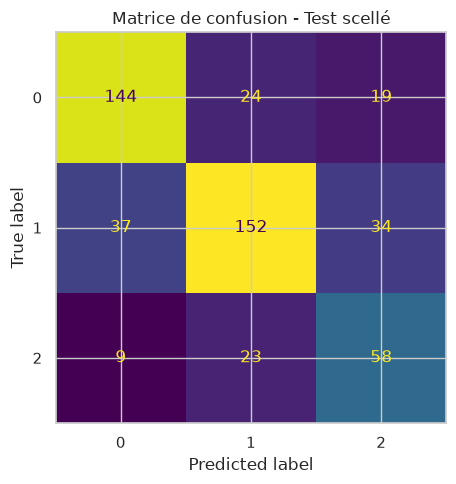

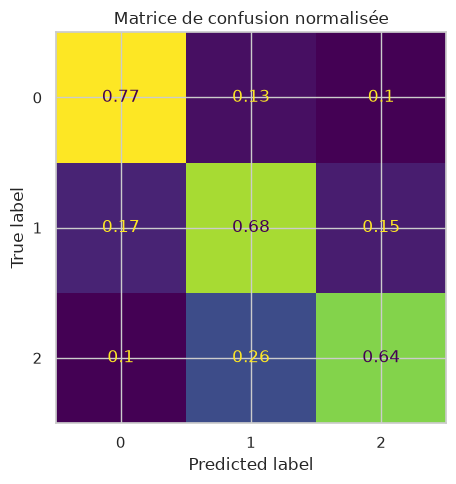

In [60]:
import matplotlib.pyplot as plt

from src.evaluation import evaluate_test_set

final_pipeline, y_pred, metrics = evaluate_test_set(
    model=model_params["LR_C0.1"],
    preprocessor=build_preprocessor(**scenarios["S1"]),
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)


# =====================================================
# Affichage métriques globales
# =====================================================

print("=" * 60)
print("ÉVALUATION FINALE - JEU DE TEST")
print("=" * 60)

print(f"Accuracy          : {metrics['accuracy']:.3f}")
print(f"Balanced Accuracy : {metrics['balanced_accuracy']:.3f}")
print(f"F1 Macro          : {metrics['f1_macro']:.3f}")
print(f"Recall Classe 2   : {metrics['recall_classe_2']:.3f}")

# =====================================================
# Rapport détaillé
# =====================================================

print("\nClassification Report")
print("-" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        digits=3
    )
)

# =====================================================
# Matrice de confusion brute
# =====================================================

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    colorbar=False
)

ax.set_title("Matrice de confusion - Test scellé")

plt.tight_layout()
plt.show()


# =====================================================
# Matrice de confusion normalisée
# =====================================================

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize="true",
    ax=ax,
    colorbar=False
)

ax.set_title("Matrice de confusion normalisée")

plt.tight_layout()
plt.show()

### 5.7 📝 Synthèse modélisation

- **Approche retenue**
  - Machine Learning classique, adapté au faible volume de données et aux variables tabulaires et textuelles.
  - Validation croisée stratifiée à **5 plis**, réalisée uniquement sur le jeu d’entraînement.
  - Comparaison de quatre modèles : régression logistique, Random Forest, LightGBM et XGBoost.

- **Meilleur secnario** (hors considérations étiques)
  - **S1**, intégrant les variables numériques, catégorielles et textuelles.
  - Meilleures performances globales, ce qui confirme la complémentarité des différentes familles de variables.

- **Choix du modèle**
  - LightGBM obtient le meilleur F1 macro du benchmark : **0,700**.
  - La régression logistique est retenue pour son meilleur compromis :
    - meilleur recall de la classe 2 : **0,696** ;
    - bonne stabilité : **σ = 0,011** ;
    - entraînement et inférence rapides ;
    - forte explicabilité.

- **Optimisation**
  - Modèle final : régression logistique avec `C = 0.1`, solveur `saga` et `class_weight="balanced"`.
  - Résultats en validation croisée :
    - F1 macro : **0,681**, contre 0,673 pour la baseline ;
    - Balanced Accuracy : **0,700**, contre 0,691 ;
    - recall classe 2 : **0,710**, contre 0,696.

- **Résultats sur le test scellé**
  - Accuracy : **0,708**
  - Balanced Accuracy : **0,699**
  - F1 macro : **0,687**
  - Recall classe 2 : **0,644**
  - Les performances globales sont proches de celles obtenues en validation croisée, ce qui indique une généralisation satisfaisante.

- **Points faibles**
  - La classe 2 reste la plus difficile à prédire :
    - F1-score : **0,577** ;
    - précision : **0,523** ;
    - recall inférieur à celui observé en validation croisée.
  - Le modèle manque encore environ **36 % des observations de classe 2**.
  - Des confusions persistent entre la classe 2 et les autres classes.

- **Conclusion**
  - La régression logistique régularisée constitue un compromis pertinent entre **performance, détection de la classe métier, coût de calcul et explicabilité**.
  - Les principales pistes d’amélioration concernent l’analyse des erreurs et l’ajustement des seuils de décision, sans réutiliser le jeu de test pour sélectionner le modèle.

---
## 6. Analyse des scénarios & arbitrages

🎯 **Comparer les scénarios définis en 4.3** et argumenter le compromis performance / éthique / robustesse.

Analyse des scénarios (sélection des features) d'après les résultats du 5.2 (Entrainement et valiation croisée)


### 6.1 Tableau comparatif


| Scénario | Métrique principale (F1 Macro) | Métrique métier (R Classe 2) |  Métrique Secondaire (Bal. Acc) |Coût entraînement | Coût inférence | Explicabilité | Biais (§1.5 → §3.6 → mitigé ici ?) | Verdict |
|---|---:|---:|---:|---:|---:|---|---|---|
| **S1 – Multimodal complet** | **0,673 ± 0,011** | **0,696** | 0,691 | 0,105 s | 0,0244 s | **Élevée** : modèle linéaire, coefficients auditables | Risque élevé : conservation de l’âge et de `nationalite_hors_ue`. Mitigation nécessaire par l’analyse des écarts entre groupes, la documentation et la supervision humaine. | **Meilleure performance et meilleure détection de la classe 2. À retenir sous réserve d’un encadrement éthique renforcé.** |
| **S2 – Approche éthique** | 0,645 ± 0,012 | 0,636 | 0,660 | 0,061 s | 0,0210 s | **Élevée** : modèle linéaire, coefficients auditables | Risque réduit par le retrait de l’âge et de `nationalite_hors_ue`. Des biais indirects peuvent subsister dans le texte et les variables corrélées. | **Meilleur compromis éthique, avec une perte de performance modérée par rapport à S1.** |
| **S3 – Texte seul** | 0,635 ± 0,017 | 0,661 | 0,654 | 0,021 s | 0,0149 s | **Moyenne** : poids TF-IDF inspectables, mais interprétation répartie entre de nombreux termes | Absence de variable sensible explicite, mais risque de biais implicites et de variables proxys dans les synthèses d’entretien. | Le texte apporte une information prédictive réelle, mais reste insuffisant seul. |
| **S4 – Données structurées seules** | 0,544 ± 0,021 | 0,583 | 0,570 | 0,062 s | 0,0189 s | **Élevée** : variables et coefficients directement auditables | Risque élevé : conservation de l’âge et de `nationalite_hors_ue`, sans le gain prédictif du texte. | Scénario dominé : faible performance tout en conservant les principales variables sensibles. |

### 6.2 Recommandation finale

*[reco temporaire proposée]*

Note :
> L'article 9 du RGPD interdit par principe le traitement des données révélant : *l'origine raciale ou ethnique, les opinions politiques, les convictions religieuses ou philosophiques, l'appartenance syndicale, [...], les données génétiques, la vie sexuelle ou l'orientation sexuelle*. La nationalité (UE/hors UE) n'apparait pas dans cette liste, mais reste très corrélée à une origine nationale et qui pourrait être utilisée comme substitut ("proxy") de l'origine ethnique ou de l'appartenance à un groupe protégé. Cette variable peut conduire à des différences de traitement entre catégories de population et doit donc être examinée avec prudence.

**Proposition**

Le scénario S1 est retenu car il exploite l'ensemble des informations utiles pour mieux repérer les personnes nécessitant un accompagnement renforcé. Il offre le meilleur niveau de fiabilité pour orienter les actions de suivi et prioriser les ressources d'accompagnement. Le compromis accepté est l'utilisation de variables potentiellement sensibles, compensée par des mesures de contrôle des biais, de transparence et par le maintien de la décision finale sous responsabilité humaine.

**Sources**

- [enjeux éthiques des algorithmes et de l'IA](https://www.cnil.fr/fr/comment-permettre-lhomme-de-garder-la-main-rapport-sur-les-enjeux-ethiques-des-algorithmes-et-de)
- [RGPD, article 9](https://www.cnil.fr/reglement-europeen-protection-donnees/chapitre2#Article9)


### 6.3 📝 Synthèse arbitrages

Le critère déterminant est la capacité du modèle à détecter les situations à risque de chômage de longue durée. Malgré un risque éthique plus élevé lié à certaines variables sensibles, le scénario S1 apporte le meilleur niveau de service pour les bénéficiaires. Le compromis retenu privilégie donc la performance métier, tout en encadrant son utilisation par des mesures de transparence, d'audit et de supervision humaine.

---
## 📎 Annexes

### A. Glossaire métier & technique

### B. Sources & bibliographie

- *[Datasets, articles, documentation technique consultés]*

### C. Décisions techniques détaillées

*[Justifications longues qu'on ne met pas dans le corps du notebook pour le garder lisible.]*

### D. Journal de bord

